# Predicting Term-Deposit Subscription in Bank Telemarketing
**CS-13410 Introduction to Machine Learning | Semester Project | Fall 2026**
The University of Lahore, Department of Computer Science & IT

**Dataset:** UCI Bank Marketing (`bank-full.csv`)

This notebook is built up part by part over the semester. Each part adds a clearly labelled section.

| Part | Focus | Status |
|---|---|---|
| **Part 1** | Data understanding, preprocessing and leakage-free pipeline | This section |
| Part 2 | Naive Bayes vs decision tree baseline | Next |
| Part 3 | Ensembles, regularization, hyperparameter optimisation | Planned |
| Part 4 | Neural network, unsupervised learning, interpretability and fairness | Planned |
| Part 5 | Final integration, report and viva | Planned |

---
# Part 1: Data Preparation & Leakage-Free Pipeline

## 1. Problem Framing

A Portuguese bank ran phone-based marketing campaigns to sell a *term deposit*. Most contacted clients decline, and every call costs time and money. If the bank could estimate *before* a call how likely a client is to subscribe, it could prioritise promising clients and reduce wasted calls.

| Item | Definition |
|---|---|
| **Prediction target** | `y`: whether the client subscribed to a term deposit (yes = 1, no = 0) |
| **Task type** | Binary classification |
| **Success metrics** | ROC-AUC and PR-AUC (quality of the ranking of clients), and F1 on the positive ("yes") class |
| **Why not accuracy** | Only about 12% of clients subscribe. A model that always predicts "no" would be roughly 88% accurate while finding no subscribers at all. |
| **Dataset** | UCI Bank Marketing, 45,211 clients, 16 input features (numeric, categorical and binary) |
| **Why it suits the project** | Well above 1,000 rows; mix of numeric and categorical features; realistic class imbalance, missing values and skewed variables; large enough for tree ensembles, a neural network and clustering/PCA in later parts; public data under CC BY 4.0 with no direct personal identifiers |

**Target leakage.** The feature `duration` (length of the call) is only known *after* the call ends, so it cannot be used to decide *whom to call*. The dataset documentation itself recommends discarding it for a realistic predictive model. It is removed in Section 5.

## 2. Setup

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

## 3. Loading the Data
The file is semicolon-separated, so `sep=";"` is required.

In [ ]:
candidates = [Path("bank/bank-full.csv"), Path("../bank/bank-full.csv"), Path("bank-full.csv"), Path("data/bank-full.csv")]
DATA_PATH = next((p for p in candidates if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("bank-full.csv not found. Place it in the 'bank/' folder next to this notebook.")

df = pd.read_csv(DATA_PATH, sep=";")
print("Rows, columns:", df.shape)
df.head()

Rows, columns: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## 4. Initial Inspection

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [ ]:
print("Duplicate rows:", df.duplicated().sum())
print("\nTarget distribution:")
print(df["y"].value_counts(normalize=True).round(3))

Duplicate rows: 0

Target distribution:
y
no     0.883
yes    0.117
Name: proportion, dtype: float64


In [ ]:
# In this dataset, missing values are written as the text "unknown"
text_cols = df.select_dtypes(exclude="number").columns
unknown_counts = (df[text_cols] == "unknown").sum()
unknown_counts[unknown_counts > 0].rename("unknown values")

job            288
education     1857
contact      13020
poutcome     36959
Name: unknown values, dtype: int64

In [ ]:
# Two numeric columns are dominated by a single constant value (a sentinel)
print(f"pdays == -1 (never contacted before): {(df['pdays'] == -1).mean():.1%}")
print(f"previous == 0:                        {(df['previous'] == 0).mean():.1%}")

pdays == -1 (never contacted before): 81.7%
previous == 0:                        81.7%


**Observations.** There are no duplicate rows. `contact`, `poutcome`, `education` and `job` contain "unknown" entries, with `poutcome` almost entirely unknown. `pdays` uses -1 as a code for "never contacted before", and 81.7% of clients have it. `previous` is 0 for the same 81.7%. These two columns need special handling because a standard IQR outlier rule would collapse them to a single value (Q1 = Q3).

## 5. Row-Level Cleaning
The steps below act on one row at a time and learn nothing from the dataset as a whole, so they are safe to apply before splitting.

1. Convert the text `"unknown"` to a true missing value (`NaN`).
2. Remove duplicate rows (none in this dataset, but kept for robustness).
3. Encode the target: `y` to 0/1.
4. Drop `duration` (target leakage, see Section 1).
5. Construct `previously_contacted` (1 if `pdays != -1`) and replace the `-1` sentinel in `pdays` by 0, so that -1 is not interpreted as a number of days.

In [ ]:
df = df.replace("unknown", np.nan)
df = df.drop_duplicates()
df["y"] = (df["y"] == "yes").astype(int)

df = df.drop(columns=["duration"])                                   # target leakage

df["previously_contacted"] = (df["pdays"] != -1).astype(int)         # feature construction
df["pdays"] = df["pdays"].replace(-1, 0)                             # sentinel handled

print("Shape after row-level cleaning:", df.shape)

Shape after row-level cleaning: (45211, 17)


## 6. Train/Test Split
The data is split **before** any step that learns from data (imputation, scaling, clipping, feature selection). The 20% test set is held out untouched and will only be used for final evaluation in later parts. Stratification keeps the share of subscribers identical in both sets.

In [ ]:
X = df.drop(columns="y")
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print(f"Subscription rate  train: {y_train.mean():.3f} | test: {y_test.mean():.3f}")

Train: (36168, 16) | Test: (9043, 16)
Subscription rate  train: 0.117 | test: 0.117


## 7. Exploratory Data Analysis
All analysis uses the **training set only**, so no decision is influenced by the held-out test data.

In [ ]:
train = X_train.assign(y=y_train)

### 7.1 Target distribution

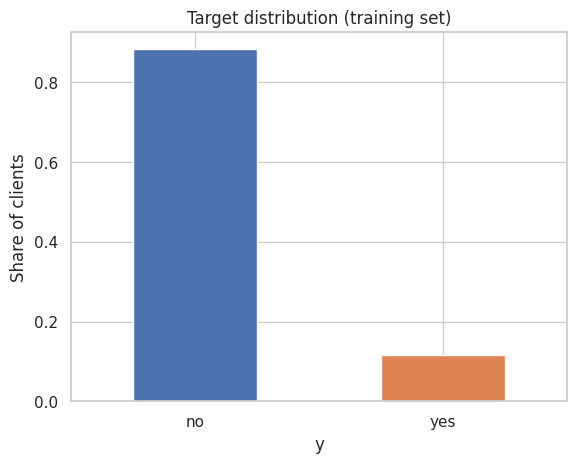

In [ ]:
ax = y_train.map({0: "no", 1: "yes"}).value_counts(normalize=True).plot(kind="bar", rot=0, color=["#4C72B0", "#DD8452"])
ax.set_title("Target distribution (training set)")
ax.set_ylabel("Share of clients")
plt.show()

**Finding.** Only 11.7% of clients subscribe, roughly one in nine. The target is clearly imbalanced, so accuracy would be misleading. We use ROC-AUC, PR-AUC and F1, and apply class weighting in the model.

### 7.2 Skewed numeric features and outliers

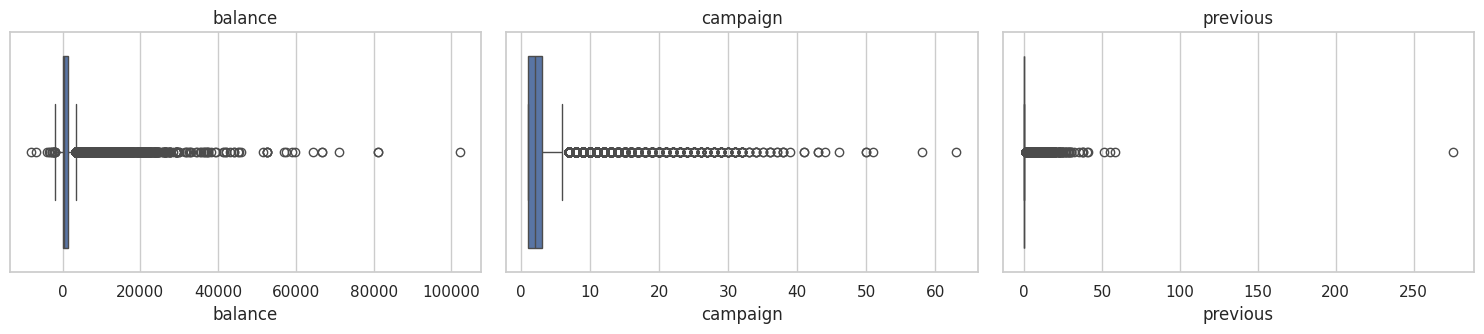

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, c in zip(axes, ["balance", "campaign", "previous"]):
    sns.boxplot(x=train[c], ax=ax)
    ax.set_title(c)
plt.tight_layout()
plt.show()

**Finding.** `balance`, `campaign` and `previous` are strongly right-skewed with extreme values. `balance` ranges from about -8,000 to over 100,000 while its 99th percentile is only about 13,000. `campaign` reaches 63 contacts (99th percentile about 16). `previous` has a median of 0 but a maximum of 275. These extremes would dominate scaled features, so these three columns are clipped at the 1st and 99th percentiles, with the limits learned from training data only.

### 7.3 Subscription rate by job

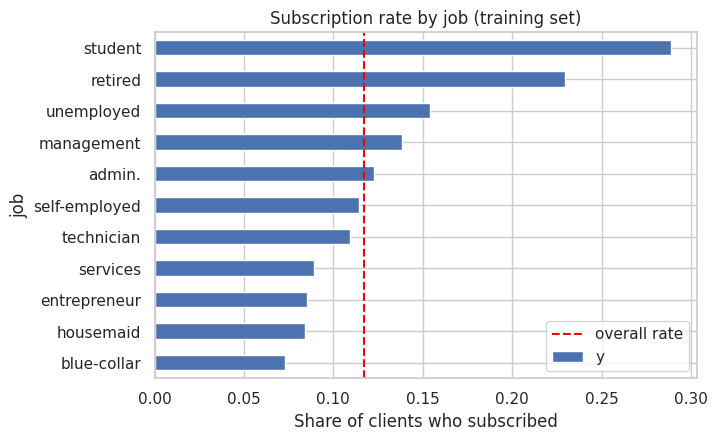

In [ ]:
rate = train.groupby("job")["y"].mean().sort_values()
ax = rate.plot(kind="barh", figsize=(7, 4.5), color="#4C72B0")
ax.axvline(y_train.mean(), color="red", linestyle="--", label="overall rate")
ax.set_title("Subscription rate by job (training set)")
ax.set_xlabel("Share of clients who subscribed")
ax.legend()
plt.show()

**Finding.** Subscription rates differ strongly by occupation. Students (about 29%) and retired clients (about 23%) subscribe far more often than average, while blue-collar clients (about 7%) subscribe least. `job` is therefore an informative feature and is one-hot encoded.

### 7.4 Missing values

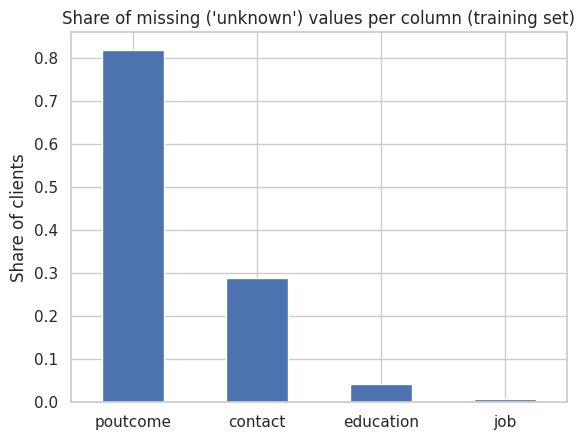

In [ ]:
missing_share = X_train.isna().mean()
missing_share = missing_share[missing_share > 0].sort_values(ascending=False)
ax = missing_share.plot(kind="bar", rot=0, color="#4C72B0")
ax.set_title("Share of missing ('unknown') values per column (training set)")
ax.set_ylabel("Share of clients")
plt.show()

**Finding.** `poutcome` is unknown for about 82% of clients and `contact` for about 29%, while `education` (about 4%) and `job` (about 0.6%) have few. For `poutcome` and `contact`, the missing entries carry meaning (mostly "not previously contacted"), so they are kept as their own `"unknown"` category instead of being replaced with the most common value, which would invent information. `job` and `education` are imputed with the most frequent value.

### 7.5 Correlation between numeric features

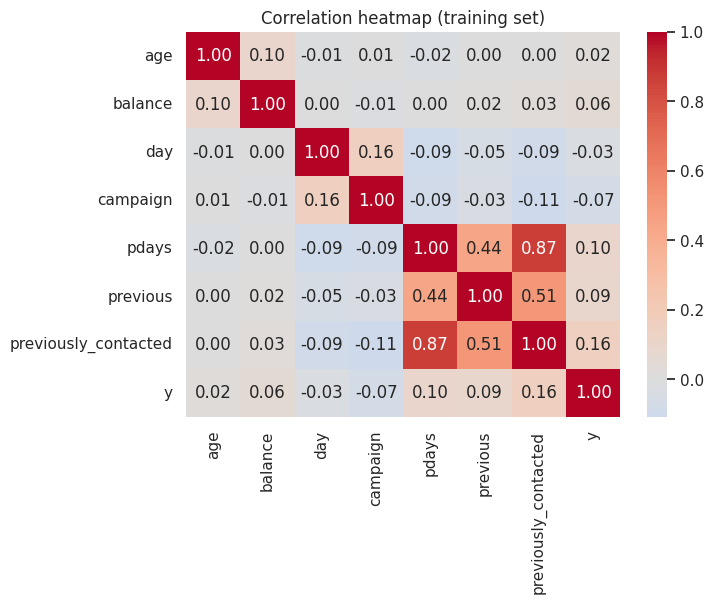

In [ ]:
num_for_corr = X_train.select_dtypes("number").assign(y=y_train)
plt.figure(figsize=(7, 5))
sns.heatmap(num_for_corr.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation heatmap (training set)")
plt.show()

**Finding.** `pdays` and `previously_contacted` are strongly correlated (about 0.87), which is expected because the second was constructed from the first. Other numeric pairs are only weakly correlated. Both are kept for now; later parts will examine whether the redundancy matters for each model family.

## 8. Preprocessing Decisions

| Issue | Decision | Rationale | Why it does not leak |
|---|---|---|---|
| Missing numeric values | Median imputation | Median is robust to the skew seen in EDA | Median is learned on training data only (inside the pipeline) |
| Missing `contact`, `poutcome` | Constant imputation with `"unknown"` | Missingness is informative (no previous campaign) | A fixed constant, so nothing is learned |
| Missing `job`, `education` | Most-frequent imputation | Very few missing; keeps all rows | Learned on training data only |
| Outliers in `balance`, `campaign`, `previous` | Clip at 1st and 99th percentile | IQR rule fails on zero-inflated columns (Q1 = Q3) | Limits learned on training data only |
| Feature scales | `StandardScaler` | Needed by linear models and neural networks | Mean and std learned on training data only |
| Categorical features | One-hot encoding, `handle_unknown="ignore"` | No artificial ordering; unseen categories do not crash | Categories learned from training data |
| Sentinel `pdays = -1` | `previously_contacted` flag and `pdays = 0` | Prevents -1 being read as a number of days | Row-level, learns nothing |
| Class imbalance (11.7% positive) | `class_weight="balanced"` | Penalises errors on the minority class more | Model setting only |
| Many encoded columns | `SelectKBest` (ANOVA F-test, k = 20) | Keeps the most informative features | Refitted inside every cross-validation fold |

## 9. Leakage-Free Pipeline
A scikit-learn `Pipeline` bundles all preprocessing and the model into a single estimator. During cross-validation it is refitted from scratch on each training fold, so imputers, clipper, scaler, encoder and feature selector only ever learn from training data and never from the validation fold.

In [ ]:
class PercentileClipper(BaseEstimator, TransformerMixin):
    """Clip each column to its [low, high] percentiles, estimated in fit() on training data only."""
    def __init__(self, low=1, high=99):
        self.low = low
        self.high = high

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.lower_, self.upper_ = np.nanpercentile(X, [self.low, self.high], axis=0)
        return self

    def transform(self, X):
        return np.clip(np.asarray(X, dtype=float), self.lower_, self.upper_)

    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features, dtype=object)

In [ ]:
clip_cols     = ["balance", "campaign", "previous"]                 # skewed / zero-inflated numeric
plain_cols    = ["age", "day", "pdays", "previously_contacted"]     # no clipping needed
cat_const     = ["contact", "poutcome"]                             # "unknown" is meaningful
cat_frequent  = [c for c in X_train.select_dtypes(exclude="number").columns if c not in cat_const]

print("Clipped numeric   :", clip_cols)
print("Plain numeric     :", plain_cols)
print("Categorical (const):", cat_const)
print("Categorical (freq) :", cat_frequent)

clip_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("clip",   PercentileClipper(low=1, high=99)),
    ("scale",  StandardScaler()),
])
plain_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale",  StandardScaler()),
])
cat_const_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
cat_freq_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer([
    ("clip",      clip_pipe,      clip_cols),
    ("plain",     plain_pipe,     plain_cols),
    ("cat_const", cat_const_pipe, cat_const),
    ("cat_freq",  cat_freq_pipe,  cat_frequent),
])

full_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("select", SelectKBest(score_func=f_classif, k=20)),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
])
full_pipeline

Clipped numeric   : ['balance', 'campaign', 'previous']
Plain numeric     : ['age', 'day', 'pdays', 'previously_contacted']
Categorical (const): ['contact', 'poutcome']
Categorical (freq) : ['job', 'marital', 'education', 'default', 'housing', 'loan', 'month']


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('select', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('clip', ...), ('plain', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

## 10. Pipeline Validation
The complete pipeline is evaluated with stratified 5-fold cross-validation on the **training set only**. Logistic regression serves as a simple placeholder estimator to verify that the pipeline works end to end; proper model comparison begins in Part 2.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = cross_validate(
    full_pipeline, X_train, y_train, cv=cv,
    scoring=["roc_auc", "average_precision", "f1"],
)

summary = pd.DataFrame({
    "metric": ["ROC-AUC", "PR-AUC", "F1 (yes class)"],
    "mean": [results["test_roc_auc"].mean(), results["test_average_precision"].mean(), results["test_f1"].mean()],
    "std":  [results["test_roc_auc"].std(),  results["test_average_precision"].std(),  results["test_f1"].std()],
}).round(3)
summary

,metric,mean,std
0,ROC-AUC,0.749,0.001
1,PR-AUC,0.382,0.007
2,F1 (yes class),0.356,0.005


**Interpretation.** The pipeline reaches a ROC-AUC of about 0.75: a randomly chosen subscriber is ranked above a randomly chosen non-subscriber about three times in four. PR-AUC is about 0.38, roughly three times the 0.117 a model with no skill would achieve (the share of subscribers). The standard deviations across folds are very small, so the pipeline behaves consistently. The modest absolute level is expected: `duration`, the most predictive feature, was deliberately removed to avoid target leakage, so the model only uses information available before the call.

In [ ]:
full_pipeline.fit(X_train, y_train)
pre = full_pipeline.named_steps["preprocess"]
selected = full_pipeline.named_steps["select"].get_support()

print("Input features              :", X_train.shape[1])
print("Columns after encoding      :", pre.transform(X_train).shape[1])
print("Columns kept by SelectKBest :", int(selected.sum()))
print()
print("Selected features:")
for name in pre.get_feature_names_out()[selected]:
    print(" -", name)

Input features              : 16
Columns after encoding      : 49
Columns kept by SelectKBest : 20

Selected features:
 - clip__balance
 - clip__campaign
 - clip__previous
 - plain__pdays
 - plain__previously_contacted
 - cat_const__contact_cellular
 - cat_const__contact_unknown
 - cat_const__poutcome_success
 - cat_const__poutcome_unknown
 - cat_freq__job_blue-collar
 - cat_freq__job_retired
 - cat_freq__job_student
 - cat_freq__housing_no
 - cat_freq__housing_yes
 - cat_freq__loan_no
 - cat_freq__month_dec
 - cat_freq__month_mar
 - cat_freq__month_may
 - cat_freq__month_oct
 - cat_freq__month_sep


## 11. Leakage Check: Why the Pipeline Matters
To illustrate the principle, the numeric features are scaled in two ways and scored with the same cross-validation folds:

- **Incorrect:** the scaler is fitted on the whole training set *before* cross-validation, so it has already seen every validation fold.
- **Correct:** the scaler is part of the pipeline and is refitted on each training fold only.

In [ ]:
num_all = clip_cols + plain_cols
X_num = X_train[num_all].fillna(X_train[num_all].median())

# Incorrect: scaler fitted on all data before cross-validation
X_scaled_leaky = StandardScaler().fit_transform(X_num)
leaky = cross_val_score(LogisticRegression(max_iter=1000, class_weight="balanced"),
                        X_scaled_leaky, y_train, cv=cv, scoring="roc_auc")

# Correct: scaler inside the pipeline
safe_pipe = Pipeline([("scale", StandardScaler()),
                      ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))])
safe = cross_val_score(safe_pipe, X_num, y_train, cv=cv, scoring="roc_auc")

print(f"Scaler fitted before CV (leaky): ROC-AUC = {leaky.mean():.4f}")
print(f"Scaler inside pipeline (safe):   ROC-AUC = {safe.mean():.4f}")

Scaler fitted before CV (leaky): ROC-AUC = 0.6478
Scaler inside pipeline (safe):   ROC-AUC = 0.6478


**Note.** For simple standard scaling the two scores are almost identical, because the mean and standard deviation of tens of thousands of rows barely change from fold to fold. The leakage risk grows with steps that use the *target* (such as feature selection or oversampling) and with small datasets. Putting every fitted step inside the pipeline removes the risk by construction, regardless of its size here.

## 12. Part 1 Summary

- **Problem:** predict whether a bank client subscribes to a term deposit (binary classification), evaluated with ROC-AUC, PR-AUC and F1.
- **Leakage controls:** `duration` removed as target leakage; data split before any learned preprocessing; all fitted steps inside a single `Pipeline`; test set untouched.
- **Cleaning and preparation:** "unknown" converted to missing; informative missingness (`contact`, `poutcome`) kept as its own category; remaining missing values imputed; skewed columns clipped at the 1st/99th percentile; `pdays` sentinel handled with a `previously_contacted` flag; numeric features standardised; categoricals one-hot encoded; 20 features selected.
- **Imbalance:** handled with class weighting (11.7% positive class).
- **Baseline pipeline performance (CV, training set):** ROC-AUC about 0.75, PR-AUC about 0.38, F1 about 0.36.
- **Outputs for later parts:** `full_pipeline`, `preprocess`, `X_train`, `X_test`, `y_train`, `y_test`.
- **Limitation:** the data is ordered roughly by time, but a stratified random split was used. A deployed model would predict future campaigns from past ones, so a time-based split would be a more realistic evaluation.



---
## References and Acknowledgements

- Moro, S., Cortez, P., & Rita, P. (2014). *A data-driven approach to predict the success of bank telemarketing.* Decision Support Systems, 62, 22-31.
- UCI Machine Learning Repository: Bank Marketing dataset. https://archive.ics.uci.edu/dataset/222/bank+marketing
- Pedregosa et al. (2011). *Scikit-learn: Machine learning in Python.* Journal of Machine Learning Research, 12, 2825-2830.
- The notebook structure and code were developed with assistance from Claude (Anthropic). The group ran, reviewed and validated all code and results.